In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

%matplotlib inline

**图形类型1：折线图——训练曲线（科研最常用）**

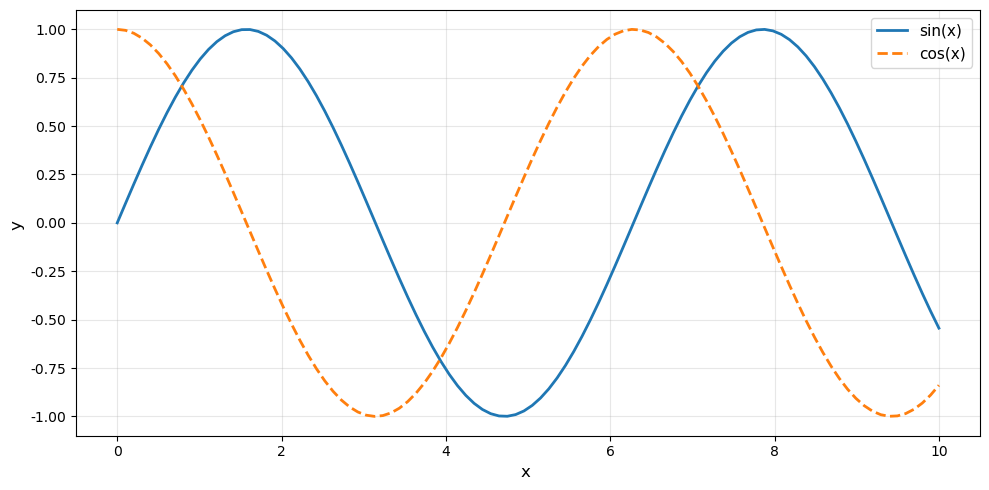

In [11]:

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y1, label='sin(x)', color='#1f77b4', linewidth=2)
plt.plot(x, y2, label='cos(x)', color='#ff7f0e', linewidth=2, linestyle='--')

plt.title('', fontsize=14)
plt.xlabel('x ', fontsize=12)
plt.ylabel('y ', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**图形类型2：混淆矩阵（分类任务必用**

matrix：
[[5 1]
 [1 5]]




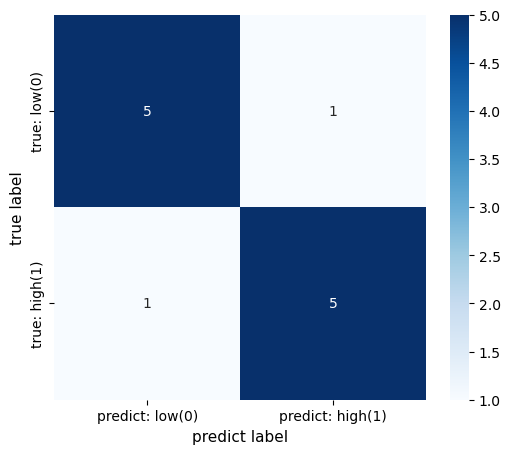

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
%matplotlib inline


y_true = [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0]
y_pred = [0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0]
class_names = ['low(0)', 'high(1)']


cm = confusion_matrix(y_true, y_pred)
print("matrix：")
print(cm)
print("\n" + "="*50 + "\n")


plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'predict: {c}' for c in class_names],
    yticklabels=[f'true: {c}' for c in class_names]
)
plt.title('', fontsize=13)
plt.ylabel('true label', fontsize=11)
plt.xlabel('predict label', fontsize=11)
plt.show()


**图形类型3：条形图——模型性能对比（实验报告必用）**

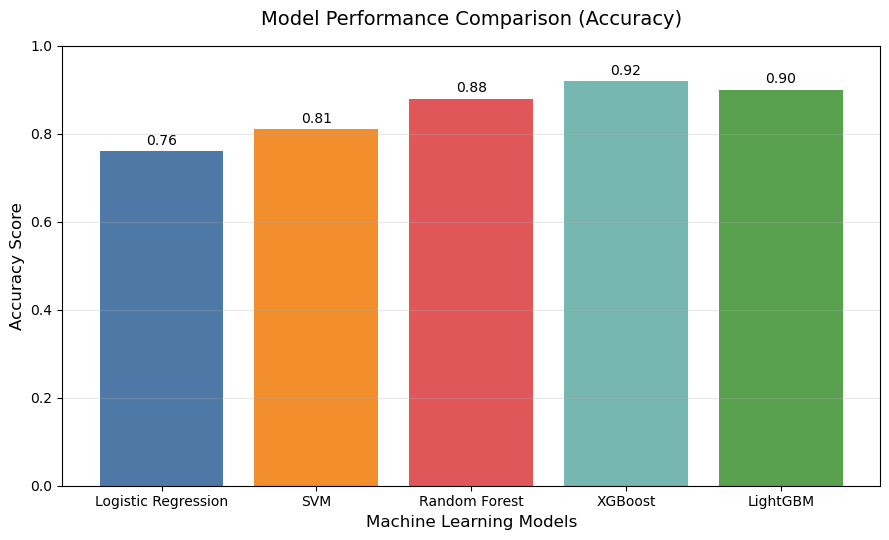

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline


model_names = ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost', 'LightGBM']
accuracy_scores = [0.76, 0.81, 0.88, 0.92, 0.90]


plt.figure(figsize=(9, 5.5))
bars = plt.bar(model_names, accuracy_scores, color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f'])


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.008,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10
    )


plt.title('Model Performance Comparison (Accuracy)', fontsize=14, pad=15)
plt.xlabel('Machine Learning Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.0)          
plt.grid(axis='y', alpha=0.3)  
plt.tight_layout()        

plt.show()

**图形类型4：ROC 曲线（二分类必用）**

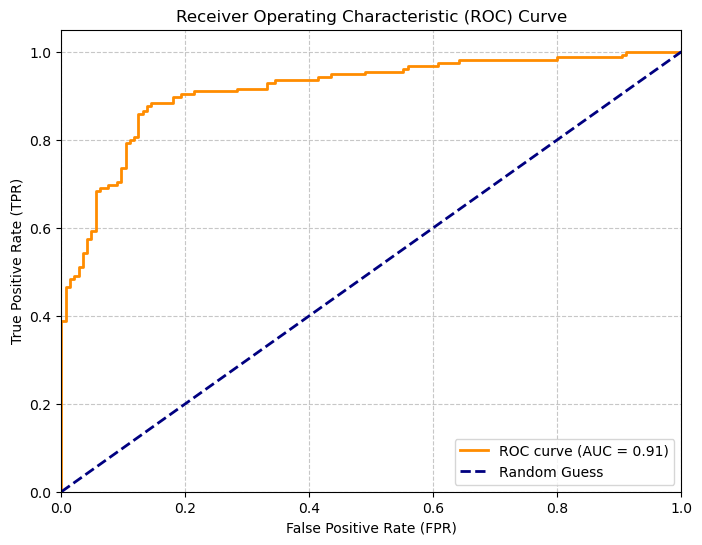

In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split


X, y = make_classification(
    n_samples=1000, n_features=20, random_state=42
)

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


model = LogisticRegression()
model.fit(X_train, y_train)


y_scores = model.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC curve (AUC = {roc_auc:.2f})",
)
plt.plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess"
)


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()

**图形类型5：t-SNE 特征空间可视化**

/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


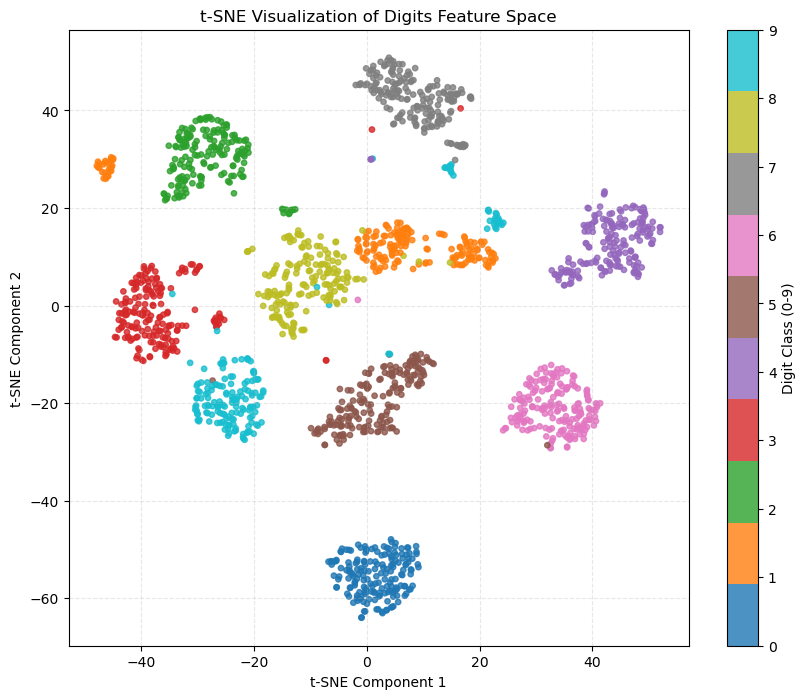

In [1]:
import os
# 强制所有数学库单线程运行，彻底避免线程冲突
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['NUMBA_NUM_THREADS'] = '1'


import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE


digits = load_digits()
X = digits.data  # Shape: (1797, 64)
y = digits.target  # Shape: (1797,)


tsne = TSNE(
    n_components=2, perplexity=30, random_state=42, n_iter=1000, init="pca"
)
X_tsne = tsne.fit_transform(X)  

plt.figure(figsize=(10, 8))


scatter = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="tab10", s=15, alpha=0.8
)


plt.colorbar(scatter, label="Digit Class (0-9)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Digits Feature Space")
plt.grid(True, linestyle="--", alpha=0.3)


plt.show()